# 01 - Análisis exploratorio de datos

Este notebook revisa el conjunto de datos, define la variable objetivo binaria y localiza patrones iniciales relacionados con abandono estudiantil.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## Carga y revisión inicial

Se importa el dataset original y se comprueba su tamaño, tipos de variables y presencia de valores nulos. Esta parte justifica la estrategia de preprocesado posterior.

In [2]:
df = pd.read_csv("../data/dataset.csv")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
print("Shape:", df.shape)
print("\nTipos:\n", df.dtypes)
print("\nNulos por columna:\n", df.isnull().sum())

Shape: (4424, 35)

Tipos:
 Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender                                              int64
Scholarship holder                           

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

## Variable objetivo

El problema se formula como clasificación binaria: `Dropout` se codifica como 1 y el resto de situaciones como 0. También se revisa el desbalance entre clases.

In [5]:
print(df["Target"].value_counts())
print(df["Target"].value_counts(normalize=True) * 100)

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


In [6]:
df["Target_bin"] = (df["Target"] == "Dropout").astype(int)
df[["Target", "Target_bin"]].head()

,Target,Target_bin
0,Dropout,1
1,Graduate,0
2,Dropout,1
3,Graduate,0
4,Graduate,0


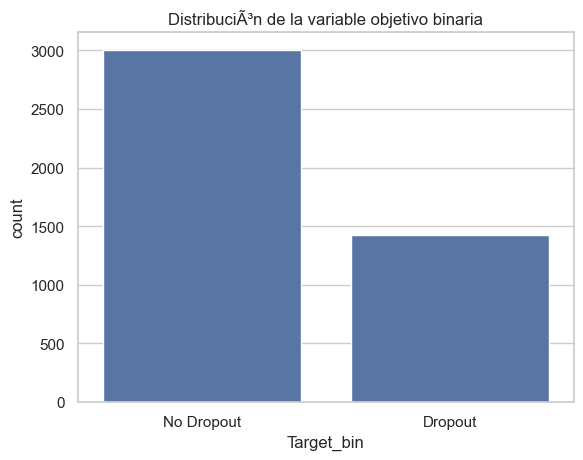

In [7]:
sns.countplot(data=df, x="Target_bin")
plt.title("DistribuciÃƒÂ³n de la variable objetivo binaria")
plt.xticks([0, 1], ["No Dropout", "Dropout"])
plt.show()

## Variables numéricas

Se resumen y visualizan variables académicas y económicas. El objetivo es detectar rangos, dispersión y posibles diferencias entre estudiantes que abandonan y los que no.

In [8]:
numeric_cols = [
    "Age at enrollment",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

categorical_cols = [c for c in df.columns if c not in numeric_cols + ["Target", "Target_bin"]]

print("NumÃƒÂ©ricas:", numeric_cols)
print("\nCategÃƒÂ³ricas:", categorical_cols)

NumÃƒÂ©ricas: ['Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']

CategÃƒÂ³ricas: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']


In [9]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age at enrollment,4424.0,23.265145,7.587816,17.00,19.00,20.000000,25.000000,70.000000
Curricular units 1st sem (credited),4424.0,0.709991,2.360507,0.00,0.00,0.000000,0.000000,20.000000
Curricular units 1st sem (enrolled),4424.0,6.270570,2.480178,0.00,5.00,6.000000,7.000000,26.000000
Curricular units 1st sem (evaluations),4424.0,8.299051,4.179106,0.00,6.00,8.000000,10.000000,45.000000
Curricular units 1st sem (approved),4424.0,4.706600,3.094238,0.00,3.00,5.000000,6.000000,26.000000
Curricular units 1st sem (grade),4424.0,10.640822,4.843663,0.00,11.00,12.285714,13.400000,18.875000
Curricular units 1st sem (without evaluations),4424.0,0.137658,0.690880,0.00,0.00,0.000000,0.000000,12.000000
Curricular units 2nd sem (credited),4424.0,0.541817,1.918546,0.00,0.00,0.000000,0.000000,19.000000
Curricular units 2nd sem (enrolled),4424.0,6.232143,2.195951,0.00,5.00,6.000000,7.000000,23.000000
Curricular units 2nd sem (evaluations),4424.0,8.063291,3.947951,0.00,6.00,8.000000,10.000000,33.000000


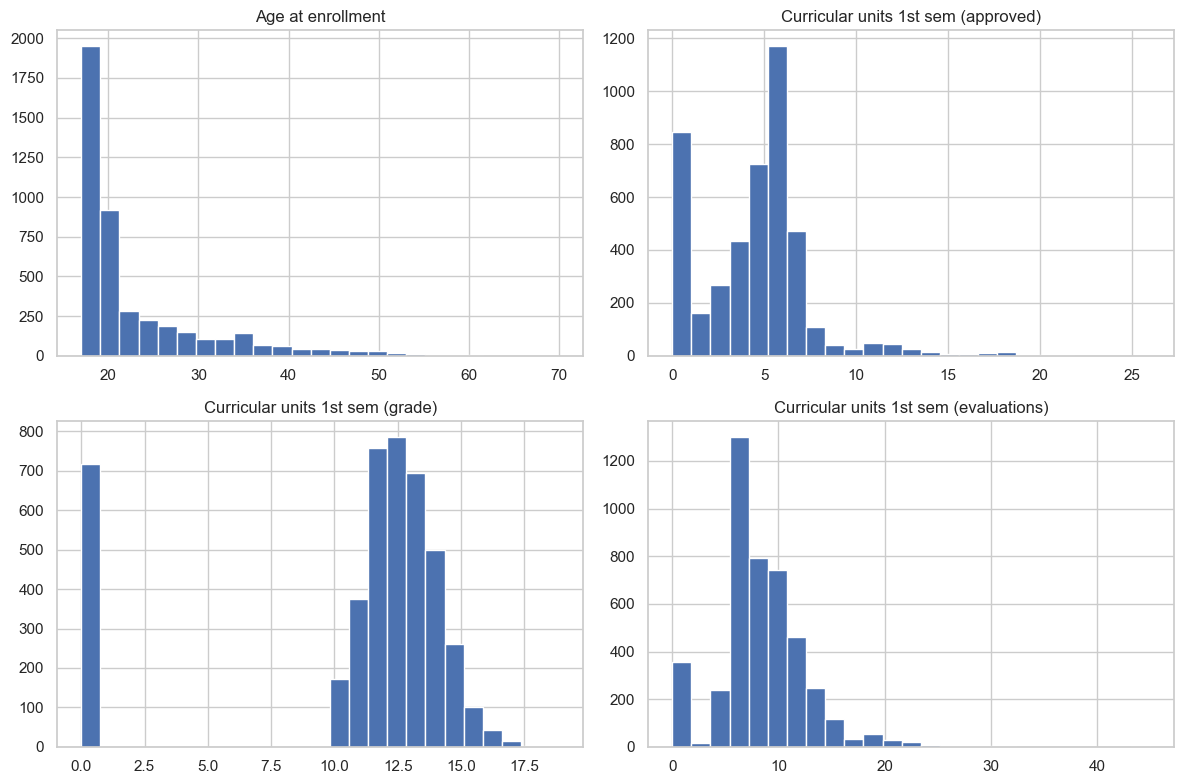

In [10]:
cols_plot = [
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (evaluations)"
]

df[cols_plot].hist(figsize=(12, 8), bins=25)
plt.tight_layout()
plt.show()

C:\Users\pablo\AppData\Local\Temp\ipykernel_21672\690388416.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Dropout", "Dropout"])
C:\Users\pablo\AppData\Local\Temp\ipykernel_21672\690388416.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Dropout", "Dropout"])
C:\Users\pablo\AppData\Local\Temp\ipykernel_21672\690388416.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Dropout", "Dropout"])
C:\Users\pablo\AppData\Local\Temp\ipykernel_21672\690388416.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Dropout", "Dropout"])


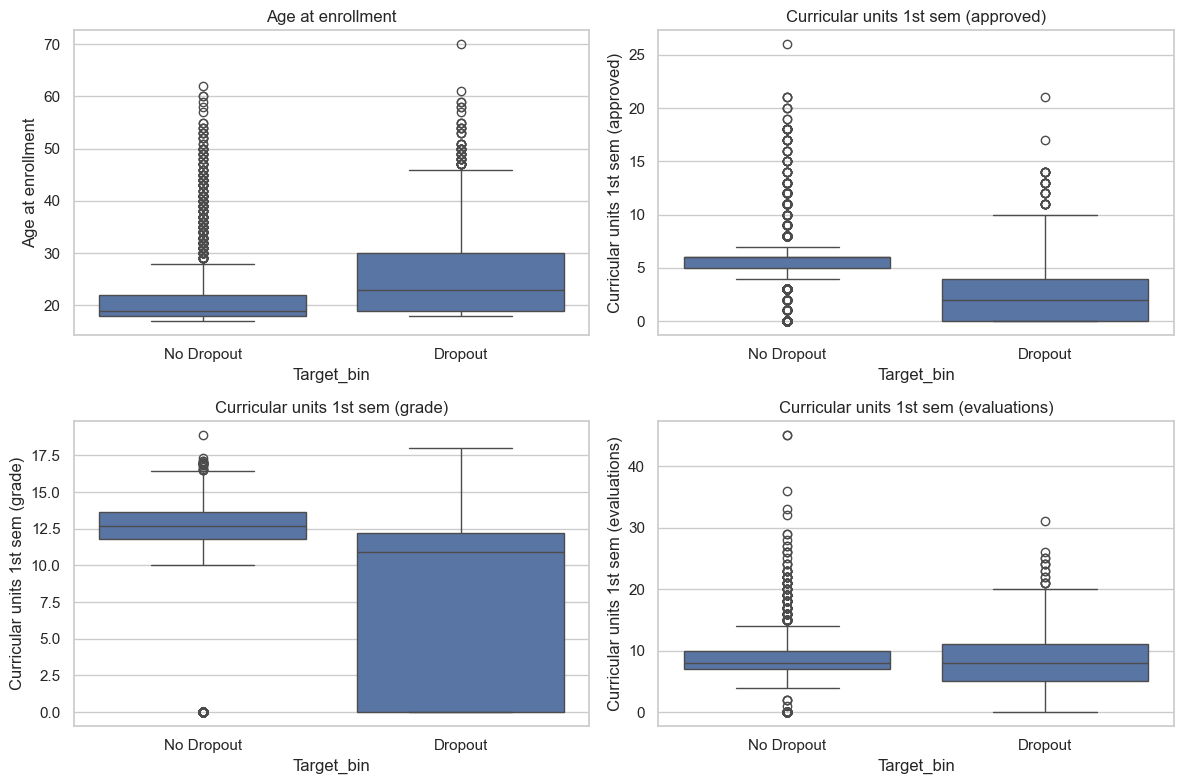

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), cols_plot):
    sns.boxplot(data=df, x="Target_bin", y=col, ax=ax)
    ax.set_xticklabels(["No Dropout", "Dropout"])
    ax.set_title(col)

plt.tight_layout()
plt.show()

## Variables sensibles y subgrupos

Se exploran variables potencialmente relevantes para equidad, como género, beca, deuda, tasas al día e internacionalidad. Estas variables se retoman en el análisis de fairness.

In [12]:
sensitive_cols = ["Gender", "Scholarship holder", "Debtor", "Tuition fees up to date", "International"]
for col in sensitive_cols:
    print(f"\n{col}")
    print(pd.crosstab(df[col], df["Target_bin"], normalize="index"))


Gender
Target_bin         0         1
Gender                        
0           0.748954  0.251046
1           0.549486  0.450514

Scholarship holder
Target_bin                 0         1
Scholarship holder                    
0                   0.612932  0.387068
1                   0.878071  0.121929

Debtor
Target_bin         0         1
Debtor                        
0           0.717164  0.282836
1           0.379722  0.620278

Tuition fees up to date
Target_bin                      0         1
Tuition fees up to date                    
0                        0.134470  0.865530
1                        0.752567  0.247433

International
Target_bin            0         1
International                    
0              0.678025  0.321975
1              0.709091  0.290909


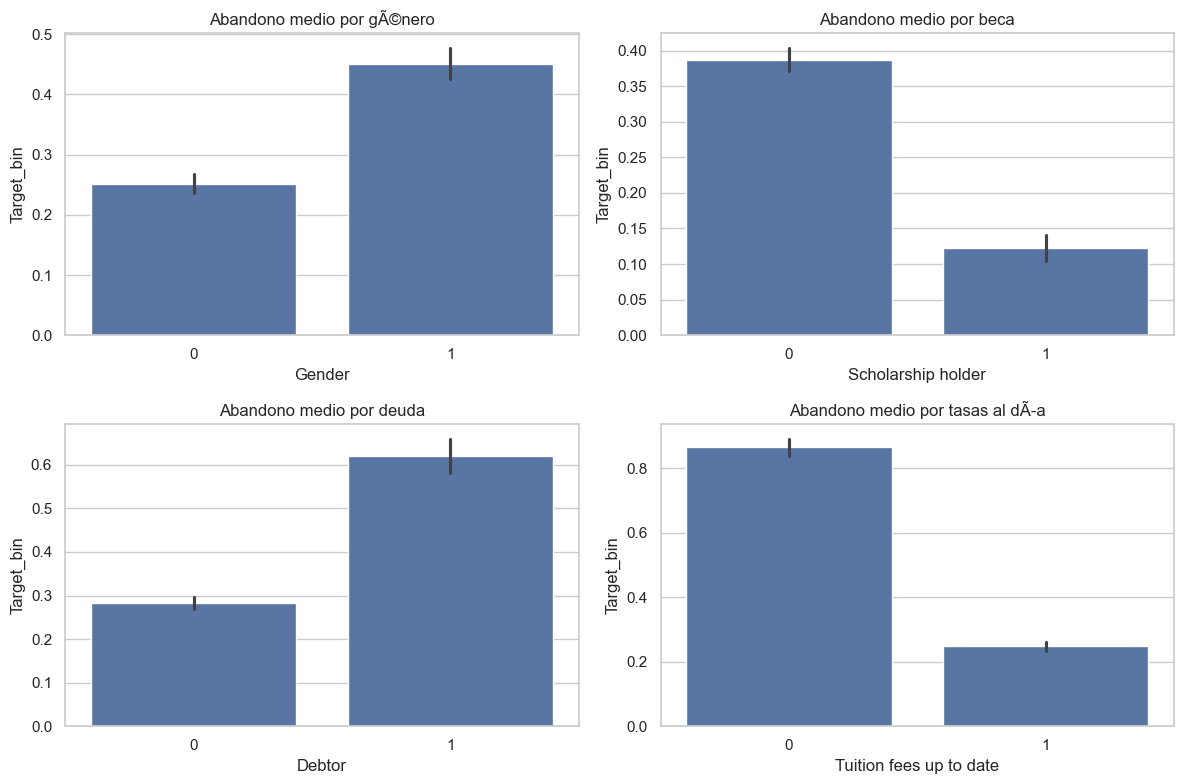

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.barplot(data=df, x="Gender", y="Target_bin", ax=axes[0,0])
axes[0,0].set_title("Abandono medio por gÃƒÂ©nero")

sns.barplot(data=df, x="Scholarship holder", y="Target_bin", ax=axes[0,1])
axes[0,1].set_title("Abandono medio por beca")

sns.barplot(data=df, x="Debtor", y="Target_bin", ax=axes[1,0])
axes[1,0].set_title("Abandono medio por deuda")

sns.barplot(data=df, x="Tuition fees up to date", y="Target_bin", ax=axes[1,1])
axes[1,1].set_title("Abandono medio por tasas al dÃƒÂ­a")

plt.tight_layout()
plt.show()

## Correlaciones

La matriz de correlación ayuda a identificar relaciones lineales con la variable objetivo y posibles redundancias entre predictores numéricos.

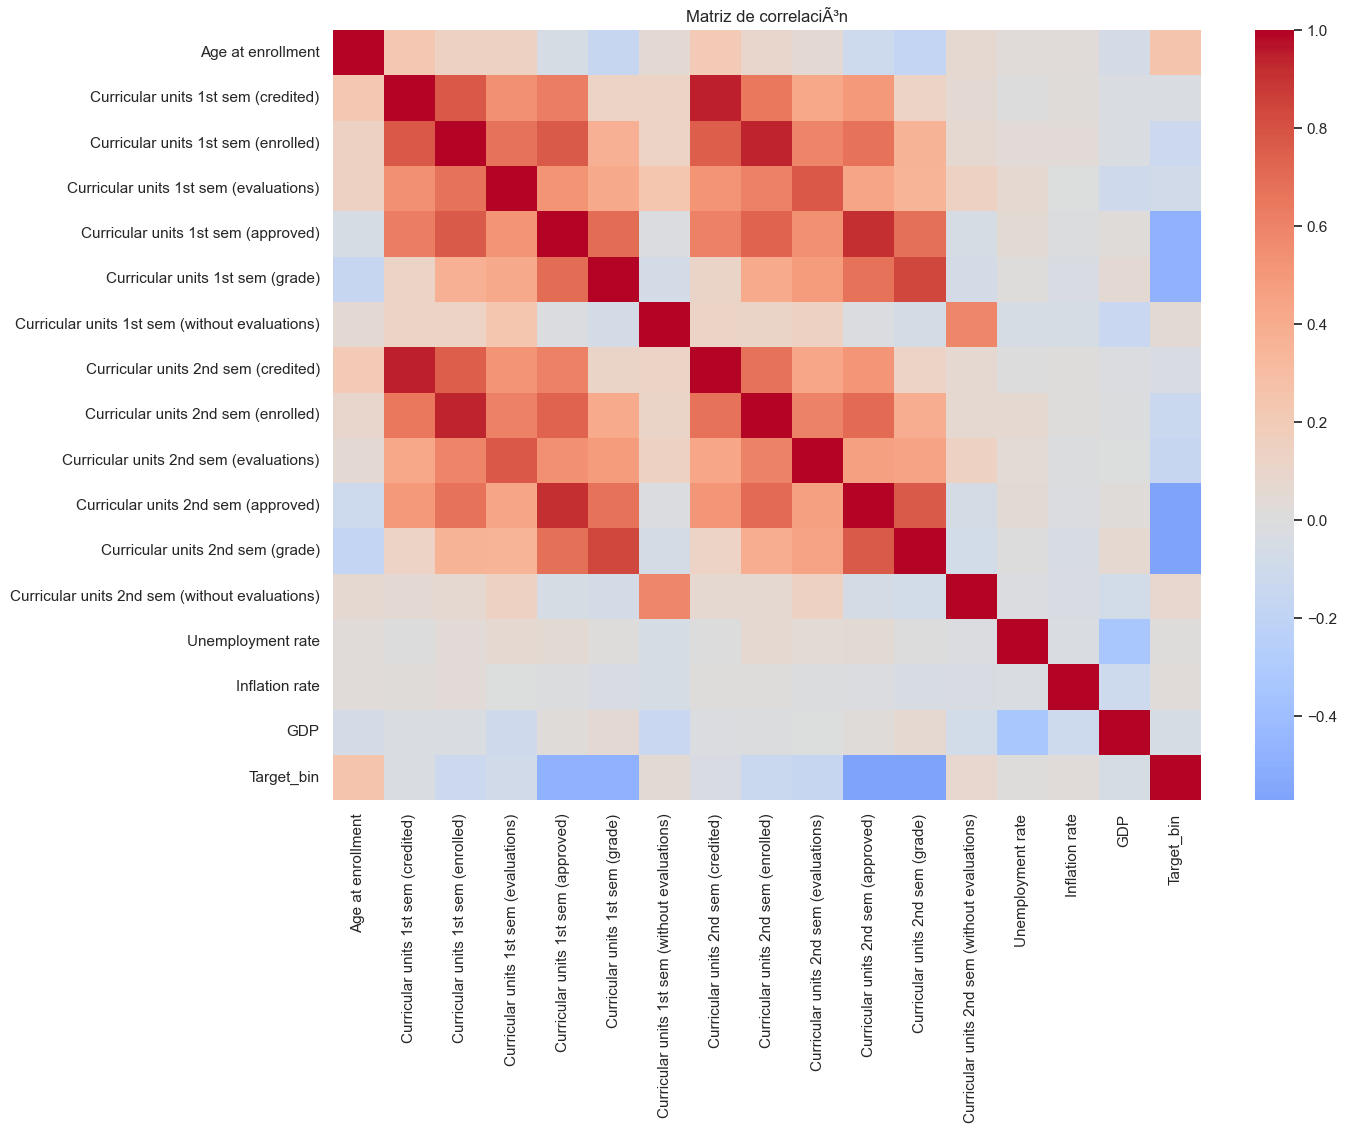

In [14]:
corr = df[numeric_cols + ["Target_bin"]].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlaciÃƒÂ³n")
plt.show()